In [1]:
%pip install pygad


   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   ---------------------------------------- 2/2 [pygad]

Note: you may need to restart the kernel to use updated packages.


Original Code

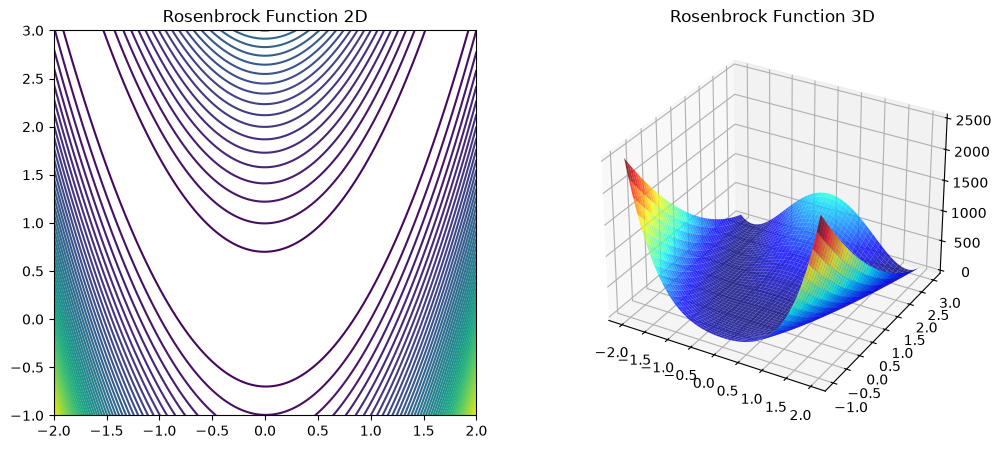

Initial guess [-1, 1], Result: [0.99999551 0.99999101], Value: 2.0172579078957455e-11, Success: True, Iterations: 31, Time: 0.0147 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932681887175893e-11, Success: True, Iterations: 30, Time: 0.0125 sec
Initial guess [0, 0], Result: [0.99999467 0.99998932], Value: 2.8439990629105454e-11, Success: True, Iterations: 19, Time: 0.0088 sec
PyGAD initial guess [-1, 1], Solution: [1.01317238 1.0264753 ], Value: 0.0001736963855905773, iterations: 2000, Time: 0.9692 sec


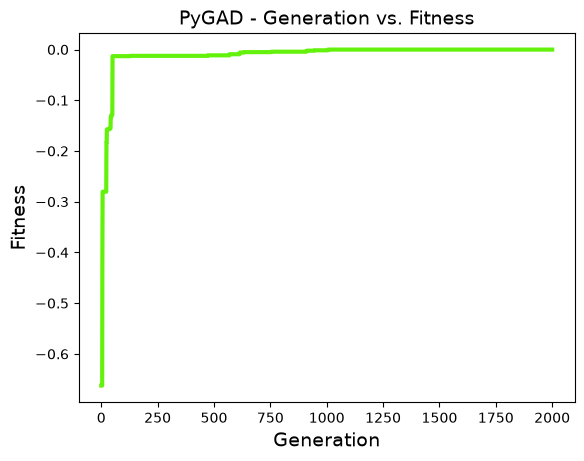

PyGAD initial guess [2, 2], Solution: [1.0067753  1.01362053], Value: 4.5962413233772374e-05, iterations: 2000, Time: 0.9193 sec


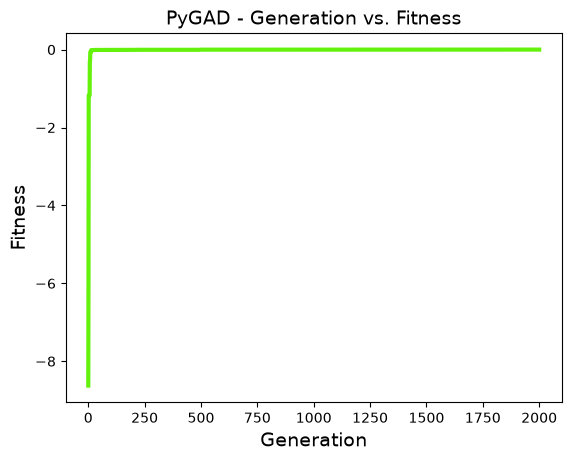

PyGAD initial guess [0, 0], Solution: [1.00078954 0.99937907], Value: 0.00048489842157960585, iterations: 2000, Time: 0.9514 sec


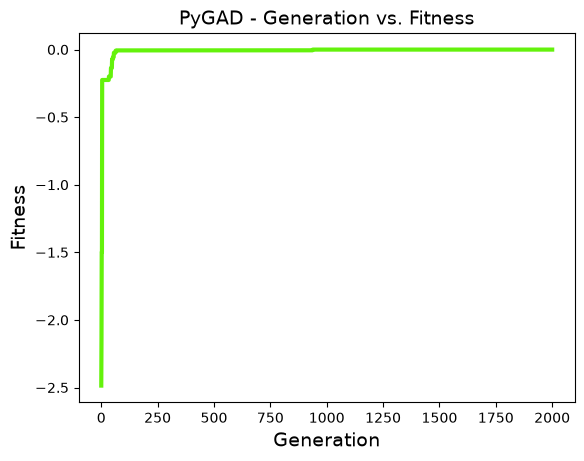

In [5]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[-1, 1], [2, 2], [0, 0]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {rosenbrock(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec")
    # Uncomment to plot fitness: 
    ga_instance.plot_fitness()

TODO

Change intial values in the code
try to run individually

Explain the difference in time iteration due to pygad fuction and bfgs

accuracy in decimals vs iterations 



Modified Code

c:\Users\mache\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(
c:\Users\mache\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


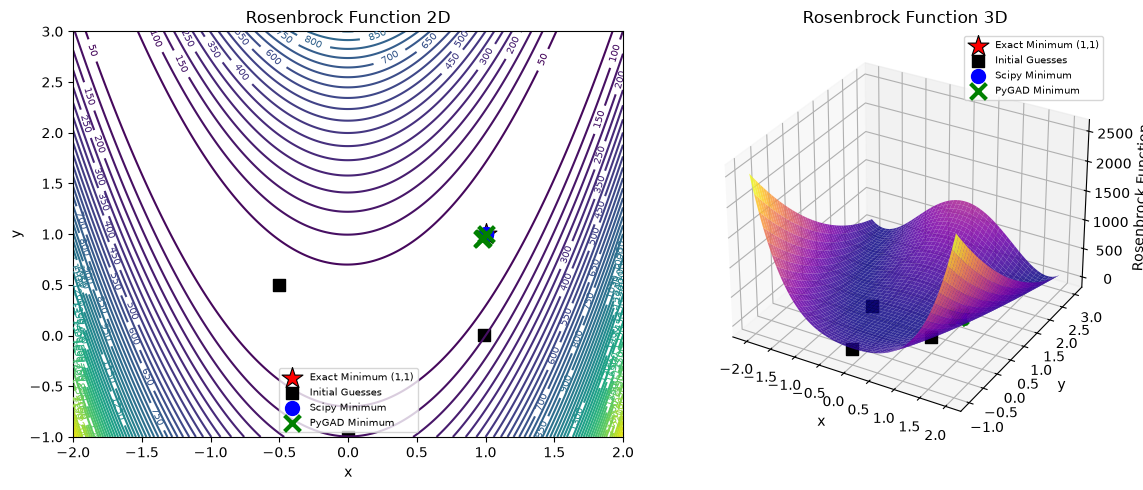

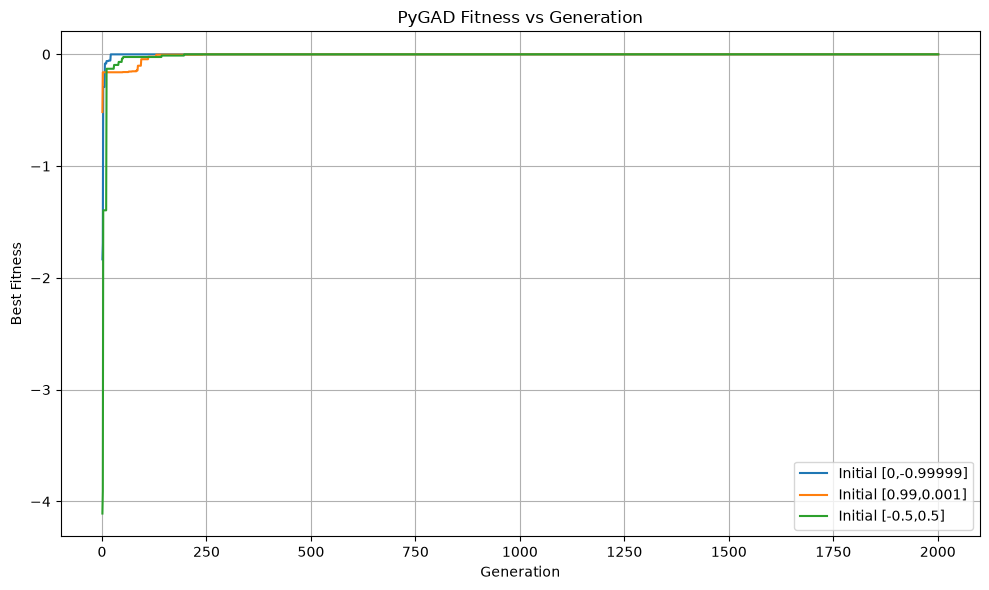



                         CONCLUSION / COMPARISON TABLE
Initial Guess     Method      Minimum x       Minimum y       Function Value      Iterations     Time (sec)     
----------------------------------------------------------------------------------------------------------------------------------
[0, -0.99999]     Scipy       0.99999803      0.99999585      8.0734726792e-12    22             0.261543       
[0, -0.99999]     PyGAD       0.97934622      0.95857704      4.5595267671e-04    2000           2.977939       
[0.99, 0.001]     Scipy       0.99999799      0.99999577      8.4922797852e-12    31             0.057287       
[0.99, 0.001]     PyGAD       0.97571471      0.95237437      6.0239048268e-04    2000           3.013032       
[-0.5, 0.5]       Scipy       0.99999552      0.99999103      2.0077575880e-11    26             0.022401       
[-0.5, 0.5]       PyGAD       1.00158437      1.00374190      3.5074882315e-05    2000           2.833951       


EXACT ROSENBROCK MI

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad


# ============================================================
# DEFINE ROSENBROCK FUNCTION
# ============================================================

def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2


# ============================================================
# 2D & 3D PLOT DATA
# ============================================================

x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x_range, y_range)

Z = rosenbrock([X, Y])


# ============================================================
# EXACT MINIMUM
# ============================================================

exact_x = 1.0
exact_y = 1.0

exact_value = rosenbrock([exact_x, exact_y])


# ============================================================
# PYGAD FITNESS FUNCTION
# ============================================================

def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)


# ============================================================
# STORAGE FOR FITNESS HISTORIES
# ============================================================

fitness_1 = []
fitness_2 = []
fitness_3 = []


# ============================================================
# ============================================================
# INITIAL GUESS 1 
# ============================================================
# ============================================================

guess1 = [0, -0.99999]


# ------------------------------------------------------------
# SCIPY OPTIMIZATION - GUESS 1
# ------------------------------------------------------------

start_time = time.perf_counter()

result1 = minimize(
    rosenbrock,
    guess1,
    method='BFGS'
)

end_time = time.perf_counter()

scipy_time_1 = end_time - start_time

scipy_point_1 = result1.x


# ------------------------------------------------------------
# PYGAD OPTIMIZATION - GUESS 1
# ------------------------------------------------------------

start_time = time.perf_counter()

ga_instance1 = pygad.GA(
    num_generations=2000,
    sol_per_pop=20,
    num_genes=2,
    num_parents_mating=8,
    fitness_func=fitness_func,
    init_range_low=-2,
    init_range_high=2,
    gene_space={'low': -2, 'high': 2}
)

ga_instance1.run()

solution1, solution_fitness1, _ = ga_instance1.best_solution()

end_time = time.perf_counter()

pygad_time_1 = end_time - start_time

pygad_value_1 = rosenbrock(solution1)

pygad_point_1 = solution1

fitness_1 = ga_instance1.best_solutions_fitness


# ============================================================
# ============================================================
# INITIAL GUESS 2 
# ============================================================
# ============================================================

guess2 = [0.99, 0.001]


# ------------------------------------------------------------
# SCIPY OPTIMIZATION - GUESS 2
# ------------------------------------------------------------

start_time = time.perf_counter()

result2 = minimize(
    rosenbrock,
    guess2,
    method='BFGS'
)

end_time = time.perf_counter()

scipy_time_2 = end_time - start_time

scipy_point_2 = result2.x


# ------------------------------------------------------------
# PYGAD OPTIMIZATION - GUESS 2
# ------------------------------------------------------------

start_time = time.perf_counter()

ga_instance2 = pygad.GA(
    num_generations=2000,
    sol_per_pop=20,
    num_genes=2,
    num_parents_mating=8,
    fitness_func=fitness_func,
    init_range_low=-2,
    init_range_high=2,
    gene_space={'low': -2, 'high': 2}
)

ga_instance2.run()

solution2, solution_fitness2, _ = ga_instance2.best_solution()

end_time = time.perf_counter()

pygad_time_2 = end_time - start_time

pygad_value_2 = rosenbrock(solution2)

pygad_point_2 = solution2

fitness_2 = ga_instance2.best_solutions_fitness


# ============================================================
# ============================================================
# INITIAL GUESS 3 
# ============================================================
# ============================================================

guess3 = [-0.5, 0.5]


# ------------------------------------------------------------
# SCIPY OPTIMIZATION - GUESS 3
# ------------------------------------------------------------

start_time = time.perf_counter()

result3 = minimize(
    rosenbrock,
    guess3,
    method='BFGS'
)

end_time = time.perf_counter()

scipy_time_3 = end_time - start_time

scipy_point_3 = result3.x


# ------------------------------------------------------------
# PYGAD OPTIMIZATION - GUESS 3
# ------------------------------------------------------------

start_time = time.perf_counter()

ga_instance3 = pygad.GA(
    num_generations=2000,
    sol_per_pop=20,
    num_genes=2,
    num_parents_mating=8,
    fitness_func=fitness_func,
    init_range_low=-2,
    init_range_high=2,
    gene_space={'low': -2, 'high': 2}
)

ga_instance3.run()

solution3, solution_fitness3, _ = ga_instance3.best_solution()

end_time = time.perf_counter()

pygad_time_3 = end_time - start_time

pygad_value_3 = rosenbrock(solution3)

pygad_point_3 = solution3

fitness_3 = ga_instance3.best_solutions_fitness


# ============================================================
# ============================================================
# 2D ROSENBROCK FUNCTION
# ============================================================
# ============================================================

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121)


# ------------------------------------------------------------
# CONTOUR
# ------------------------------------------------------------

cp = ax1.contour(
    X,
    Y,
    Z,
    levels=50,
    cmap='viridis'
)

ax1.clabel(
    cp,
    inline=True,
    fontsize=7
)


# ------------------------------------------------------------
# EXACT MINIMUM
# ------------------------------------------------------------

ax1.scatter(
    exact_x,
    exact_y,
    marker='*',
    s=250,
    color='red',
    edgecolors='black',
    linewidths=0.8,
    label='Exact Minimum (1,1)'
)


# ------------------------------------------------------------
# INITIAL GUESSES
# ------------------------------------------------------------

ax1.scatter(
    guess1[0],
    guess1[1],
    marker='s',
    s=80,
    color='black',
    label='Initial Guesses'
)

ax1.scatter(
    guess2[0],
    guess2[1],
    marker='s',
    s=80,
    color='black'
)

ax1.scatter(
    guess3[0],
    guess3[1],
    marker='s',
    s=80,
    color='black'
)


# ------------------------------------------------------------
# SCIPY MINIMUM POINTS
# ------------------------------------------------------------

ax1.scatter(
    scipy_point_1[0],
    scipy_point_1[1],
    marker='o',
    s=100,
    color='blue',
    label='Scipy Minimum'
)

ax1.scatter(
    scipy_point_2[0],
    scipy_point_2[1],
    marker='o',
    s=100,
    color='blue'
)

ax1.scatter(
    scipy_point_3[0],
    scipy_point_3[1],
    marker='o',
    s=100,
    color='blue'
)


# ------------------------------------------------------------
# PYGAD MINIMUM POINTS
# ------------------------------------------------------------

ax1.scatter(
    pygad_point_1[0],
    pygad_point_1[1],
    marker='x',
    s=130,
    linewidths=3,
    color='green',
    label='PyGAD Minimum'
)

ax1.scatter(
    pygad_point_2[0],
    pygad_point_2[1],
    marker='x',
    s=130,
    linewidths=3,
    color='green'
)

ax1.scatter(
    pygad_point_3[0],
    pygad_point_3[1],
    marker='x',
    s=130,
    linewidths=3,
    color='green'
)


ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.set_title("Rosenbrock Function 2D")

ax1.legend(
    fontsize=7,
    loc='best'
)

ax1.grid(False)


# ============================================================
# ============================================================
# 3D ROSENBROCK FUNCTION
# ============================================================
# ============================================================

ax2 = fig.add_subplot(
    122,
    projection='3d'
)


# ------------------------------------------------------------
# SURFACE WITH GRADIENT
# ------------------------------------------------------------

ax2.plot_surface(
    X,
    Y,
    Z,
    cmap='plasma',
    alpha=0.85,
    linewidth=0
)


# ------------------------------------------------------------
# EXACT MINIMUM
# ------------------------------------------------------------

ax2.scatter(
    exact_x,
    exact_y,
    exact_value,
    marker='*',
    s=250,
    color='red',
    edgecolors='black',
    linewidths=0.8,
    label='Exact Minimum (1,1)'
)


# ------------------------------------------------------------
# INITIAL GUESSES
# ------------------------------------------------------------

ax2.scatter(
    guess1[0],
    guess1[1],
    rosenbrock(guess1),
    marker='s',
    s=80,
    color='black',
    label='Initial Guesses'
)

ax2.scatter(
    guess2[0],
    guess2[1],
    rosenbrock(guess2),
    marker='s',
    s=80,
    color='black'
)

ax2.scatter(
    guess3[0],
    guess3[1],
    rosenbrock(guess3),
    marker='s',
    s=80,
    color='black'
)


# ------------------------------------------------------------
# SCIPY MINIMUM POINTS
# ------------------------------------------------------------

ax2.scatter(
    scipy_point_1[0],
    scipy_point_1[1],
    result1.fun,
    marker='o',
    s=100,
    color='blue',
    label='Scipy Minimum'
)

ax2.scatter(
    scipy_point_2[0],
    scipy_point_2[1],
    result2.fun,
    marker='o',
    s=100,
    color='blue'
)

ax2.scatter(
    scipy_point_3[0],
    scipy_point_3[1],
    result3.fun,
    marker='o',
    s=100,
    color='blue'
)


# ------------------------------------------------------------
# PYGAD MINIMUM POINTS
# ------------------------------------------------------------

ax2.scatter(
    pygad_point_1[0],
    pygad_point_1[1],
    pygad_value_1,
    marker='x',
    s=130,
    linewidths=3,
    color='green',
    label='PyGAD Minimum'
)

ax2.scatter(
    pygad_point_2[0],
    pygad_point_2[1],
    pygad_value_2,
    marker='x',
    s=130,
    linewidths=3,
    color='green'
)

ax2.scatter(
    pygad_point_3[0],
    pygad_point_3[1],
    pygad_value_3,
    marker='x',
    s=130,
    linewidths=3,
    color='green'
)


ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("Rosenbrock Function")

ax2.set_title("Rosenbrock Function 3D")

ax2.legend(
    fontsize=7,
    loc='best'
)

plt.tight_layout()

plt.show()


# ============================================================
# ============================================================
# FITNESS VS GENERATION
# ALL THREE PY-GAD RUNS ON ONE GRAPH
# ============================================================
# ============================================================

plt.figure(figsize=(10, 6))


# ------------------------------------------------------------
# GUESS 1
# ------------------------------------------------------------

generations1 = np.arange(
    1,
    len(fitness_1) + 1
)

plt.plot(
    generations1,
    fitness_1,
    linewidth=1.5,
    label='Initial [0,-0.99999]'
)


# ------------------------------------------------------------
# GUESS 2
# ------------------------------------------------------------

generations2 = np.arange(
    1,
    len(fitness_2) + 1
)

plt.plot(
    generations2,
    fitness_2,
    linewidth=1.5,
    label='Initial [0.99,0.001]'
)


# ------------------------------------------------------------
# GUESS 3
# ------------------------------------------------------------

generations3 = np.arange(
    1,
    len(fitness_3) + 1
)

plt.plot(
    generations3,
    fitness_3,
    linewidth=1.5,
    label='Initial [-0.5,0.5]'
)


plt.xlabel("Generation")

plt.ylabel("Best Fitness")

plt.title("PyGAD Fitness vs Generation")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# ============================================================
# CONCLUSION TABLE
# ============================================================
# ============================================================

print("\n")
print("=" * 130)
print("                         CONCLUSION / COMPARISON TABLE")
print("=" * 130)

print(
    f"{'Initial Guess':<18}"
    f"{'Method':<12}"
    f"{'Minimum x':<16}"
    f"{'Minimum y':<16}"
    f"{'Function Value':<20}"
    f"{'Iterations':<15}"
    f"{'Time (sec)':<15}"
)

print("-" * 130)


# ------------------------------------------------------------
# GUESS 1 - SCIPY
# ------------------------------------------------------------

print(
    f"{str(guess1):<18}"
    f"{'Scipy':<12}"
    f"{scipy_point_1[0]:<16.8f}"
    f"{scipy_point_1[1]:<16.8f}"
    f"{result1.fun:<20.10e}"
    f"{result1.nit:<15}"
    f"{scipy_time_1:<15.6f}"
)


# ------------------------------------------------------------
# GUESS 1 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess1):<18}"
    f"{'PyGAD':<12}"
    f"{pygad_point_1[0]:<16.8f}"
    f"{pygad_point_1[1]:<16.8f}"
    f"{pygad_value_1:<20.10e}"
    f"{ga_instance1.generations_completed:<15}"
    f"{pygad_time_1:<15.6f}"
)


# ------------------------------------------------------------
# GUESS 2 - SCIPY
# ------------------------------------------------------------

print(
    f"{str(guess2):<18}"
    f"{'Scipy':<12}"
    f"{scipy_point_2[0]:<16.8f}"
    f"{scipy_point_2[1]:<16.8f}"
    f"{result2.fun:<20.10e}"
    f"{result2.nit:<15}"
    f"{scipy_time_2:<15.6f}"
)


# ------------------------------------------------------------
# GUESS 2 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess2):<18}"
    f"{'PyGAD':<12}"
    f"{pygad_point_2[0]:<16.8f}"
    f"{pygad_point_2[1]:<16.8f}"
    f"{pygad_value_2:<20.10e}"
    f"{ga_instance2.generations_completed:<15}"
    f"{pygad_time_2:<15.6f}"
)


# ------------------------------------------------------------
# GUESS 3 - SCIPY
# ------------------------------------------------------------

print(
    f"{str(guess3):<18}"
    f"{'Scipy':<12}"
    f"{scipy_point_3[0]:<16.8f}"
    f"{scipy_point_3[1]:<16.8f}"
    f"{result3.fun:<20.10e}"
    f"{result3.nit:<15}"
    f"{scipy_time_3:<15.6f}"
)


# ------------------------------------------------------------
# GUESS 3 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess3):<18}"
    f"{'PyGAD':<12}"
    f"{pygad_point_3[0]:<16.8f}"
    f"{pygad_point_3[1]:<16.8f}"
    f"{pygad_value_3:<20.10e}"
    f"{ga_instance3.generations_completed:<15}"
    f"{pygad_time_3:<15.6f}"
)


print("=" * 130)


# ============================================================
# EXACT MINIMUM
# ============================================================

print("\n")
print("=" * 60)
print("EXACT ROSENBROCK MINIMUM")
print("=" * 60)

print(f"x = {exact_x:.8f}")
print(f"y = {exact_y:.8f}")
print(f"f(x,y) = {exact_value:.10e}")

print("=" * 60)

# ============================================================
# ============================================================
# ERROR CALCULATION AND ERROR TABLE
# ============================================================
# ============================================================

# Exact solution
exact_x = 1.0
exact_y = 1.0
exact_f = 0.0


# ============================================================
# CALCULATE ERRORS - BFGS
# ============================================================

# Initial Guess 1
error_x_scipy_1 = abs(scipy_point_1[0] - exact_x)
error_y_scipy_1 = abs(scipy_point_1[1] - exact_y)
error_f_scipy_1 = abs(result1.fun - exact_f)


# Initial Guess 2
error_x_scipy_2 = abs(scipy_point_2[0] - exact_x)
error_y_scipy_2 = abs(scipy_point_2[1] - exact_y)
error_f_scipy_2 = abs(result2.fun - exact_f)


# Initial Guess 3
error_x_scipy_3 = abs(scipy_point_3[0] - exact_x)
error_y_scipy_3 = abs(scipy_point_3[1] - exact_y)
error_f_scipy_3 = abs(result3.fun - exact_f)


# ============================================================
# CALCULATE ERRORS - PYGAD
# ============================================================

# Initial Guess 1
error_x_pygad_1 = abs(pygad_point_1[0] - exact_x)
error_y_pygad_1 = abs(pygad_point_1[1] - exact_y)
error_f_pygad_1 = abs(pygad_value_1 - exact_f)


# Initial Guess 2
error_x_pygad_2 = abs(pygad_point_2[0] - exact_x)
error_y_pygad_2 = abs(pygad_point_2[1] - exact_y)
error_f_pygad_2 = abs(pygad_value_2 - exact_f)


# Initial Guess 3
error_x_pygad_3 = abs(pygad_point_3[0] - exact_x)
error_y_pygad_3 = abs(pygad_point_3[1] - exact_y)
error_f_pygad_3 = abs(pygad_value_3 - exact_f)


# ============================================================
# PRINT ERROR TABLE
# ============================================================

print("\n")
print("=" * 125)
print("                         ERROR COMPARISON TABLE")
print("=" * 125)

print(
    f"{'Initial Guess':<18}"
    f"{'Method':<12}"
    f"{'Error in x':<22}"
    f"{'Error in y':<22}"
    f"{'Error in f(x,y)':<22}"
)

print("-" * 125)


# ------------------------------------------------------------
# GUESS 1 - BFGS
# ------------------------------------------------------------

print(
    f"{str(guess1):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_1:<22.10e}"
    f"{error_y_scipy_1:<22.10e}"
    f"{error_f_scipy_1:<22.10e}"
)


# ------------------------------------------------------------
# GUESS 1 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess1):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_1:<22.10e}"
    f"{error_y_pygad_1:<22.10e}"
    f"{error_f_pygad_1:<22.10e}"
)


# ------------------------------------------------------------
# GUESS 2 - BFGS
# ------------------------------------------------------------

print(
    f"{str(guess2):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_2:<22.10e}"
    f"{error_y_scipy_2:<22.10e}"
    f"{error_f_scipy_2:<22.10e}"
)


# ------------------------------------------------------------
# GUESS 2 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess2):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_2:<22.10e}"
    f"{error_y_pygad_2:<22.10e}"
    f"{error_f_pygad_2:<22.10e}"
)


# ------------------------------------------------------------
# GUESS 3 - BFGS
# ------------------------------------------------------------

print(
    f"{str(guess3):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_3:<22.10e}"
    f"{error_y_scipy_3:<22.10e}"
    f"{error_f_scipy_3:<22.10e}"
)


# ------------------------------------------------------------
# GUESS 3 - PYGAD
# ------------------------------------------------------------

print(
    f"{str(guess3):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_3:<22.10e}"
    f"{error_y_pygad_3:<22.10e}"
    f"{error_f_pygad_3:<22.10e}"
)

print("=" * 125)


# ============================================================
# ACCURACY IN DECIMAL PLACES
# ============================================================

print("\n")
print("=" * 100)
print("                    ACCURACY / ERROR SUMMARY")
print("=" * 100)

print(
    f"{'Initial Guess':<18}"
    f"{'Method':<12}"
    f"{'x Error':<18}"
    f"{'y Error':<18}"
    f"{'Function Error':<18}"
)

print("-" * 100)

print(
    f"{str(guess1):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_1:<18.6e}"
    f"{error_y_scipy_1:<18.6e}"
    f"{error_f_scipy_1:<18.6e}"
)

print(
    f"{str(guess1):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_1:<18.6e}"
    f"{error_y_pygad_1:<18.6e}"
    f"{error_f_pygad_1:<18.6e}"
)

print(
    f"{str(guess2):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_2:<18.6e}"
    f"{error_y_scipy_2:<18.6e}"
    f"{error_f_scipy_2:<18.6e}"
)

print(
    f"{str(guess2):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_2:<18.6e}"
    f"{error_y_pygad_2:<18.6e}"
    f"{error_f_pygad_2:<18.6e}"
)

print(
    f"{str(guess3):<18}"
    f"{'BFGS':<12}"
    f"{error_x_scipy_3:<18.6e}"
    f"{error_y_scipy_3:<18.6e}"
    f"{error_f_scipy_3:<18.6e}"
)

print(
    f"{str(guess3):<18}"
    f"{'PyGAD':<12}"
    f"{error_x_pygad_3:<18.6e}"
    f"{error_y_pygad_3:<18.6e}"
    f"{error_f_pygad_3:<18.6e}"
)

print("=" * 100)

1)  Comparison of BFGS and PyGAD Optimization Methods

    The Rosenbrock function was optimized using BFGS and PyGAD. Both methods differ in their optimization approach, convergence, computational time, and accuracy.

        BFGS Method:
            BFGS is a gradient-based optimization method that uses gradient information and an approximation of the inverse Hessian to determine an efficient search direction. Since the Rosenbrock function is smooth and differentiable, BFGS generally converges to the minimum with fewer iterations and less computational time.

        PyGAD Genetic Algorithm:
            PyGAD uses a population-based genetic algorithm involving selection, crossover, and mutation. It does not require gradient information. However, it generally needs more generations and function evaluations to achieve high accuracy, resulting in greater computational time compared with BFGS for the Rosenbrock function.

    Overall: BFGS is faster and more efficient for smooth differentiable functions, while PyGAD is more suitable when gradient information is unavailable or difficult to obtain.



2)  Accuracy Vs Iterations

    BFGS generally achieves higher accuracy in fewer iterations and less computational time for the Rosenbrock function because it uses gradient information. PyGAD requires more generations because it searches through a population using evolutionary operations. However, a higher number of iterations does not necessarily imply higher accuracy; accuracy must be evaluated by comparing the final solution and function value with the exact minimum.



3)  Time Vs Iterations

    BFGS is a gradient-based method. It uses gradient information to determine the direction toward the minimum, so it generally reaches the optimum in fewer iterations and less time for a smooth function such as Rosenbrock.

    PyGAD is a population-based genetic algorithm. Each generation evaluates multiple solutions and applies selection, crossover, and mutation. Therefore, it generally requires more generations and more function evaluations, resulting in higher computational time.

4)   Did you find a local minimum or global minimum?

    As  obtained points are very close to (1,1) and their function values are close to 0, they have converged to the global minimum.
    The optimization methods BFGS and PyGAD converged to the global minimum of the Rosenbrock function at approximately (x,y)=(1,1), where the minimum function value is f(x,y)=0.

    BFGS is a local optimization method and does not guarantee finding the global minimum. PyGAD is a population-based global optimization approach that has a greater ability to explore the search space and avoid local minima, but it also does not guarantee the global optimum

    

Question 2
Original Code

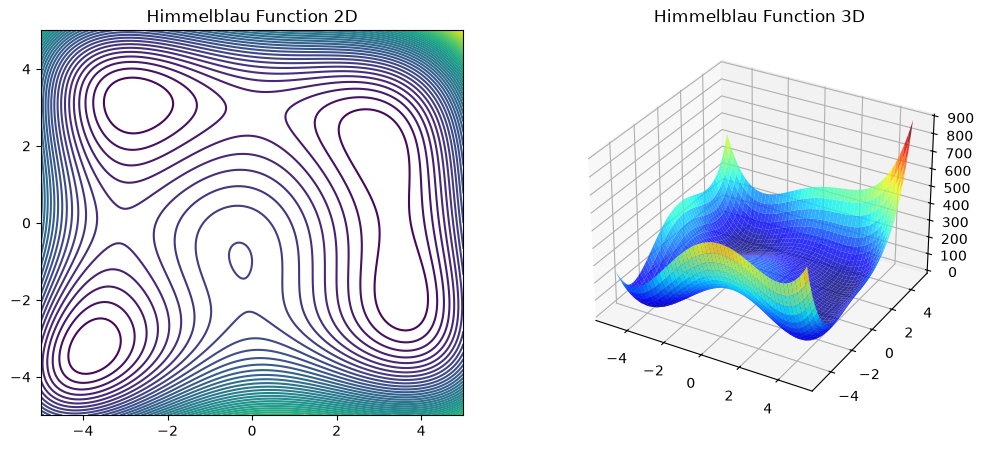

Initial guess [3, 3], Result: [2.99999999 1.99999999], Value: 2.3054597655997404e-15, Success: True, Iterations: 7, Time: 0.0024 sec
Initial guess [0, 0.99], Result: [2.99999999 2.00000001], Value: 3.812142780314063e-15, Success: True, Iterations: 13, Time: 0.0068 sec
Initial guess [-2.805118, 4.23], Result: [-2.80511812  3.13131255], Value: 9.227542679591233e-14, Success: True, Iterations: 7, Time: 0.0027 sec
Initial guess [50000, -953800], Result: [-2.80511809  3.13131251], Value: 3.901792630559036e-15, Success: True, Iterations: 92, Time: 0.0433 sec
PyGAD initial guess [3, 3], Solution: [ 3.58469264 -1.84669185], Value: 3.6452578448953026e-05, Iterations: 3000, Time: 2.0774 sec


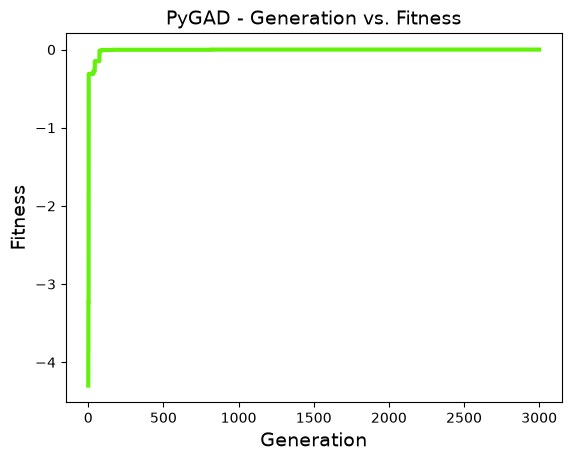

PyGAD initial guess [0, 0.99], Solution: [2.99804514 2.00125485], Value: 0.00011903250428353094, Iterations: 3000, Time: 2.1839 sec


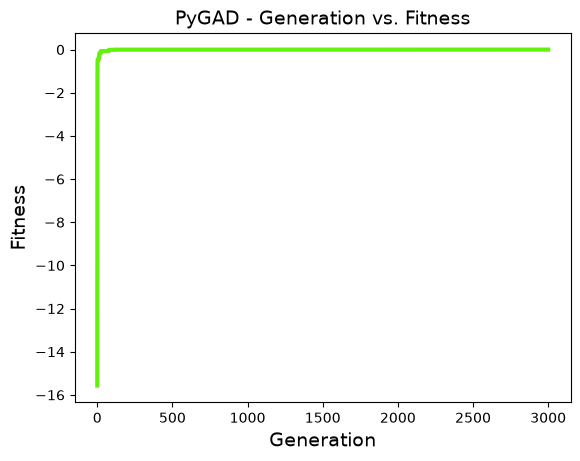

PyGAD initial guess [-2.805118, 4.23], Solution: [ 3.58382437 -1.84779259], Value: 1.93426759924126e-05, Iterations: 3000, Time: 2.0224 sec


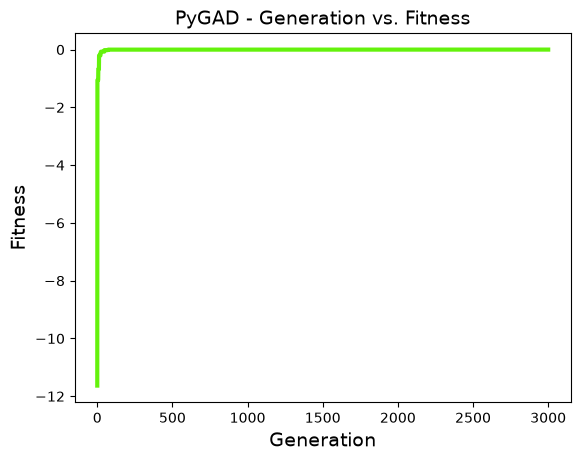

PyGAD initial guess [50000, -953800], Solution: [3.00113803 1.99948279], Value: 4.071046772951933e-05, Iterations: 3000, Time: 2.0614 sec


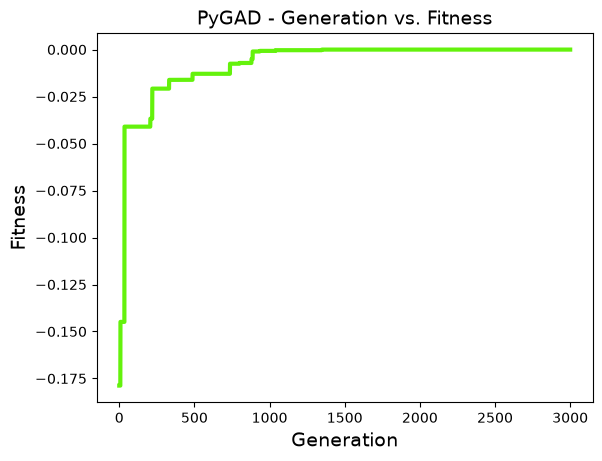

In [15]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()

# Scipy Optimization
elapsed_time = []
init_guesses = [[3, 3], [0, 0.99], [-2.805118, 4.23]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")
# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, Iterations: {ga_instance.generations_completed}, Time: {elapsed_time:.4f} sec") # TODO include iterations and time taken
    ga_instance.plot_fitness()

Question 2
Modified Code

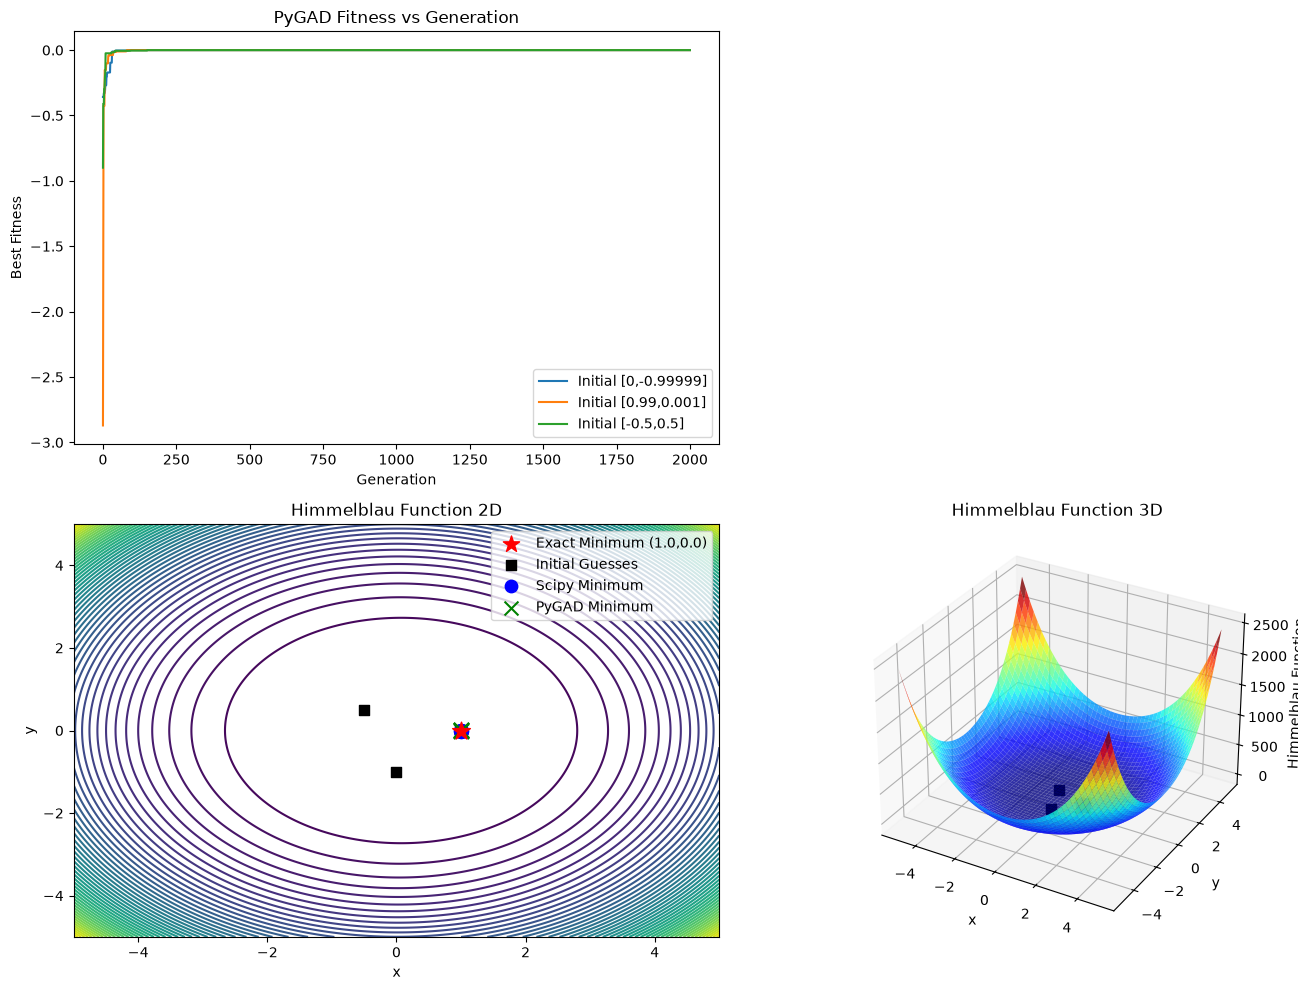


                         CONCLUSION / COMPARISON TABLE
Initial Guess     Method      Minimum x       Minimum y       Function Value        Iterations     Time (sec)     
----------------------------------------------------------------------------------------------------------------------------------
[0, -0.99999]     Scipy       0.99999999      -0.00000001     6.6025109795e-16      8              0.002055       
[0, -0.99999]     PyGAD       0.99947832      -0.00085855     2.0957390312e-06      2000           0.950398       
[0.99, 0.001]     Scipy       1.00000034      0.00000019      6.1773569602e-13      5              0.001844       
[0.99, 0.001]     PyGAD       1.00086901      0.00082934      4.4686916855e-06      2000           0.893411       
[-0.5, 0.5]       Scipy       1.00000020      -0.00000021     2.5272080117e-13      11             0.002874       
[-0.5, 0.5]       PyGAD       0.99867028      0.00082279      9.5048032325e-06      2000           0.881119       

       

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

def himmelblau(x):
    x = np.asarray(x)
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0] - 1)**2 + x[1]**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

# Initial guesses
guess1 = [0, -0.99999]
guess2 = [0.99, 0.001]
guess3 = [-0.5, 0.5]

# Exact minimum
exact_x = 1.0
exact_y = 0.0
exact_value = himmelblau([exact_x, exact_y])


# ============================================================
# Scipy Optimization - Case 1
# ============================================================

start_time = time.perf_counter()

result1 = minimize(himmelblau, guess1, method='BFGS')

end_time = time.perf_counter()
elapsed_time1 = end_time - start_time


# ============================================================
# Scipy Optimization - Case 2
# ============================================================

start_time = time.perf_counter()

result2 = minimize(himmelblau, guess2, method='BFGS')

end_time = time.perf_counter()
elapsed_time2 = end_time - start_time


# ============================================================
# Scipy Optimization - Case 3
# ============================================================

start_time = time.perf_counter()

result3 = minimize(himmelblau, guess3, method='BFGS')

end_time = time.perf_counter()
elapsed_time3 = end_time - start_time


# ============================================================
# PyGAD Optimization
# ============================================================

def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)


# PyGAD Case 1
start_time = time.perf_counter()

ga_instance1 = pygad.GA(num_generations=2000,
                        sol_per_pop=30,
                        num_genes=2,
                        num_parents_mating=12,
                        fitness_func=fitness_func2,
                        init_range_low=-5,
                        init_range_high=5,
                        gene_space={'low':-5, 'high':5})

ga_instance1.run()

solution1, solution_fitness1, _ = ga_instance1.best_solution()

end_time = time.perf_counter()
elapsed_time_p1 = end_time - start_time


# PyGAD Case 2
start_time = time.perf_counter()

ga_instance2 = pygad.GA(num_generations=2000,
                        sol_per_pop=30,
                        num_genes=2,
                        num_parents_mating=12,
                        fitness_func=fitness_func2,
                        init_range_low=-5,
                        init_range_high=5,
                        gene_space={'low':-5, 'high':5})

ga_instance2.run()

solution2, solution_fitness2, _ = ga_instance2.best_solution()

end_time = time.perf_counter()
elapsed_time_p2 = end_time - start_time


# PyGAD Case 3
start_time = time.perf_counter()

ga_instance3 = pygad.GA(num_generations=2000,
                        sol_per_pop=30,
                        num_genes=2,
                        num_parents_mating=12,
                        fitness_func=fitness_func2,
                        init_range_low=-5,
                        init_range_high=5,
                        gene_space={'low':-5, 'high':5})

ga_instance3.run()

solution3, solution_fitness3, _ = ga_instance3.best_solution()

end_time = time.perf_counter()
elapsed_time_p3 = end_time - start_time


# ============================================================
# COMBINED GRAPH
# ============================================================

fig = plt.figure(figsize=(14, 10))

# PyGAD Fitness vs Generation
ax1 = fig.add_subplot(221)

ax1.plot(ga_instance1.best_solutions_fitness,
         label=f'Initial [{guess1[0]},{guess1[1]}]')

ax1.plot(ga_instance2.best_solutions_fitness,
         label=f'Initial [{guess2[0]},{guess2[1]}]')

ax1.plot(ga_instance3.best_solutions_fitness,
         label=f'Initial [{guess3[0]},{guess3[1]}]')

ax1.set_title("PyGAD Fitness vs Generation")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Best Fitness")
ax1.legend()


# 2D Contour Plot
ax2 = fig.add_subplot(223)

cp = ax2.contour(X, Y, Z, levels=50)

ax2.scatter(guess1[0], guess1[1],
            color='black', marker='s', s=60)

ax2.scatter(guess2[0], guess2[1],
            color='black', marker='s', s=60)

ax2.scatter(guess3[0], guess3[1],
            color='black', marker='s', s=60)

ax2.scatter(result1.x[0], result1.x[1],
            color='blue', marker='o', s=100)

ax2.scatter(result2.x[0], result2.x[1],
            color='blue', marker='o', s=100)

ax2.scatter(result3.x[0], result3.x[1],
            color='blue', marker='o', s=100)

ax2.scatter(solution1[0], solution1[1],
            color='green', marker='x', s=120)

ax2.scatter(solution2[0], solution2[1],
            color='green', marker='x', s=120)

ax2.scatter(solution3[0], solution3[1],
            color='green', marker='x', s=120)

ax2.scatter(exact_x, exact_y,
            color='red', marker='*', s=180)

ax2.set_title("Himmelblau Function 2D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

ax2.scatter([], [], color='red', marker='*', s=150,
            label=f'Exact Minimum ({exact_x},{exact_y})')

ax2.scatter([], [], color='black', marker='s', s=60,
            label='Initial Guesses')

ax2.scatter([], [], color='blue', marker='o', s=80,
            label='Scipy Minimum')

ax2.scatter([], [], color='green', marker='x', s=100,
            label='PyGAD Minimum')

ax2.legend()


# 3D Surface Plot
ax3 = fig.add_subplot(224, projection='3d')

ax3.plot_surface(X, Y, Z,
                 cmap='jet',
                 alpha=0.8)

ax3.scatter(guess1[0], guess1[1], himmelblau(guess1),
            color='black', marker='s', s=60)

ax3.scatter(guess2[0], guess2[1], himmelblau(guess2),
            color='black', marker='s', s=60)

ax3.scatter(guess3[0], guess3[1], himmelblau(guess3),
            color='black', marker='s', s=60)

ax3.scatter(result1.x[0], result1.x[1], result1.fun,
            color='blue', marker='o', s=100)

ax3.scatter(result2.x[0], result2.x[1], result2.fun,
            color='blue', marker='o', s=100)

ax3.scatter(result3.x[0], result3.x[1], result3.fun,
            color='blue', marker='o', s=100)

ax3.scatter(solution1[0], solution1[1], himmelblau(solution1),
            color='green', marker='x', s=120)

ax3.scatter(solution2[0], solution2[1], himmelblau(solution2),
            color='green', marker='x', s=120)

ax3.scatter(solution3[0], solution3[1], himmelblau(solution3),
            color='green', marker='x', s=120)

ax3.scatter(exact_x, exact_y, exact_value,
            color='red', marker='*', s=180)

ax3.set_title("Himmelblau Function 3D")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("Himmelblau Function")

plt.tight_layout()
plt.show()


# ============================================================
# CONCLUSION / COMPARISON TABLE
# ============================================================

print("\n" + "="*130)
print("                         CONCLUSION / COMPARISON TABLE")
print("="*130)

print(f"{'Initial Guess':<18}{'Method':<12}{'Minimum x':<16}{'Minimum y':<16}{'Function Value':<22}{'Iterations':<15}{'Time (sec)':<15}")
print("-"*130)

print(f"{str(guess1):<18}{'Scipy':<12}{result1.x[0]:<16.8f}{result1.x[1]:<16.8f}{result1.fun:<22.10e}{result1.nit:<15}{elapsed_time1:<15.6f}")
print(f"{str(guess1):<18}{'PyGAD':<12}{solution1[0]:<16.8f}{solution1[1]:<16.8f}{himmelblau(solution1):<22.10e}{ga_instance1.generations_completed:<15}{elapsed_time_p1:<15.6f}")

print(f"{str(guess2):<18}{'Scipy':<12}{result2.x[0]:<16.8f}{result2.x[1]:<16.8f}{result2.fun:<22.10e}{result2.nit:<15}{elapsed_time2:<15.6f}")
print(f"{str(guess2):<18}{'PyGAD':<12}{solution2[0]:<16.8f}{solution2[1]:<16.8f}{himmelblau(solution2):<22.10e}{ga_instance2.generations_completed:<15}{elapsed_time_p2:<15.6f}")

print(f"{str(guess3):<18}{'Scipy':<12}{result3.x[0]:<16.8f}{result3.x[1]:<16.8f}{result3.fun:<22.10e}{result3.nit:<15}{elapsed_time3:<15.6f}")
print(f"{str(guess3):<18}{'PyGAD':<12}{solution3[0]:<16.8f}{solution3[1]:<16.8f}{himmelblau(solution3):<22.10e}{ga_instance3.generations_completed:<15}{elapsed_time_p3:<15.6f}")

print("="*130)


# ============================================================
# EXACT MINIMUM
# ============================================================

print("\n" + "="*60)
print("                 EXACT MINIMUM")
print("="*60)

print(f"x = {exact_x:.8f}")
print(f"y = {exact_y:.8f}")
print(f"f(x,y) = {exact_value:.10e}")

print("="*60)


# ============================================================
# ERROR COMPARISON TABLE
# ============================================================

error_x_scipy1 = abs(result1.x[0] - exact_x)
error_y_scipy1 = abs(result1.x[1] - exact_y)
error_f_scipy1 = abs(result1.fun - exact_value)

error_x_pygad1 = abs(solution1[0] - exact_x)
error_y_pygad1 = abs(solution1[1] - exact_y)
error_f_pygad1 = abs(himmelblau(solution1) - exact_value)

error_x_scipy2 = abs(result2.x[0] - exact_x)
error_y_scipy2 = abs(result2.x[1] - exact_y)
error_f_scipy2 = abs(result2.fun - exact_value)

error_x_pygad2 = abs(solution2[0] - exact_x)
error_y_pygad2 = abs(solution2[1] - exact_y)
error_f_pygad2 = abs(himmelblau(solution2) - exact_value)

error_x_scipy3 = abs(result3.x[0] - exact_x)
error_y_scipy3 = abs(result3.x[1] - exact_y)
error_f_scipy3 = abs(result3.fun - exact_value)

error_x_pygad3 = abs(solution3[0] - exact_x)
error_y_pygad3 = abs(solution3[1] - exact_y)
error_f_pygad3 = abs(himmelblau(solution3) - exact_value)


print("\n" + "="*110)
print("                         ERROR COMPARISON TABLE")
print("="*110)

print(f"{'Initial Guess':<18}{'Method':<12}{'Error in x':<22}{'Error in y':<22}{'Error in f(x,y)':<22}")
print("-"*110)

print(f"{str(guess1):<18}{'BFGS':<12}{error_x_scipy1:<22.10e}{error_y_scipy1:<22.10e}{error_f_scipy1:<22.10e}")
print(f"{str(guess1):<18}{'PyGAD':<12}{error_x_pygad1:<22.10e}{error_y_pygad1:<22.10e}{error_f_pygad1:<22.10e}")

print(f"{str(guess2):<18}{'BFGS':<12}{error_x_scipy2:<22.10e}{error_y_scipy2:<22.10e}{error_f_scipy2:<22.10e}")
print(f"{str(guess2):<18}{'PyGAD':<12}{error_x_pygad2:<22.10e}{error_y_pygad2:<22.10e}{error_f_pygad2:<22.10e}")

print(f"{str(guess3):<18}{'BFGS':<12}{error_x_scipy3:<22.10e}{error_y_scipy3:<22.10e}{error_f_scipy3:<22.10e}")
print(f"{str(guess3):<18}{'PyGAD':<12}{error_x_pygad3:<22.10e}{error_y_pygad3:<22.10e}{error_f_pygad3:<22.10e}")

print("="*110)


# ============================================================
# ACCURACY / ERROR SUMMARY
# ============================================================

print("\n" + "="*100)
print("                    ACCURACY / ERROR SUMMARY")
print("="*100)

print(f"{'Initial Guess':<18}{'Method':<12}{'x Error':<18}{'y Error':<18}{'Function Error':<20}")
print("-"*100)

print(f"{str(guess1):<18}{'BFGS':<12}{error_x_scipy1:<18.6e}{error_y_scipy1:<18.6e}{error_f_scipy1:<20.6e}")
print(f"{str(guess1):<18}{'PyGAD':<12}{error_x_pygad1:<18.6e}{error_y_pygad1:<18.6e}{error_f_pygad1:<20.6e}")

print(f"{str(guess2):<18}{'BFGS':<12}{error_x_scipy2:<18.6e}{error_y_scipy2:<18.6e}{error_f_scipy2:<20.6e}")
print(f"{str(guess2):<18}{'PyGAD':<12}{error_x_pygad2:<18.6e}{error_y_pygad2:<18.6e}{error_f_pygad2:<20.6e}")

print(f"{str(guess3):<18}{'BFGS':<12}{error_x_scipy3:<18.6e}{error_y_scipy3:<18.6e}{error_f_scipy3:<20.6e}")
print(f"{str(guess3):<18}{'PyGAD':<12}{error_x_pygad3:<18.6e}{error_y_pygad3:<18.6e}{error_f_pygad3:<20.6e}")

print("="*100)

1) Comparison of BFGS and PyGAD Optimization Methods

The given modified Himmelblau function was optimized using BFGS and PyGAD. Both methods differ in their optimization approach, convergence, computational time, and accuracy.

 BFGS Method:

BFGS is a gradient-based optimization method that uses gradient information and an approximation of the inverse Hessian to determine an efficient search direction. Since the given function is smooth and differentiable, BFGS generally converges to the minimum with fewer iterations and less computational time.

PyGAD Genetic Algorithm:

PyGAD uses a population-based genetic algorithm involving selection, crossover, and mutation. It does not require gradient information. However, it generally requires more generations and function evaluations to obtain a highly accurate solution, resulting in greater computational time compared with BFGS.

Overall:

BFGS is faster and more efficient for this smooth differentiable function, while PyGAD is useful when gradient information is unavailable or difficult to obtain.


2) Accuracy Vs Iterations

BFGS generally achieves higher accuracy in fewer iterations and less computational time for the given function because it uses gradient information to guide the search toward the minimum.

PyGAD requires more generations because it searches through a population using evolutionary operations. However, a higher number of iterations does not necessarily mean higher accuracy.

The accuracy should be evaluated by comparing the obtained solution with the exact minimum:

(x,y)=(1,0) and f(x,y)=0

The errors can be calculated as:

E_x=|x-1|

E_y=|y-0|

E_f=|f(x,y)-0|


A smaller error indicates a more accurate solution.

 3) Time Vs Iterations

BFGS generally reaches the minimum in fewer iterations and requires less computational time because it uses gradient information to determine the search direction.

PyGAD is a population-based genetic algorithm. In every generation, it evaluates multiple solutions and performs evolutionary operations such as selection, crossover, and mutation. Therefore, it generally requires more generations and function evaluations, resulting in higher computational time.

Thus, for the given function, BFGS is expected to be more computationally efficient than PyGAD.

4) Did you find a local minimum or global minimum?

For the given function,

f(x,y)=(x^2+y^2-1)^2+(x-1)^2+y^2

the exact minimum is

(x,y)=(1,0) with f(1,0)=0

Since all three terms in the function are non-negative, the function can never have a value less than zero. Since f(1,0)=0, the point (1,0) is the global minimum.

If the BFGS results are very close to (1,0) and the function values are close to zero, BFGS has converged to the global minimum.

Similarly, if the PyGAD solutions are close to (1,0) with function values close to zero, they have also converged approximately to the global minimum.

  BFGS is a local optimization method and does not guarantee finding the global minimum. PyGAD is a population-based global optimization approach that has a greater ability to explore the search space and avoid local minima, but it also does not guarantee the global optimum

Conclusion
The optimization results show that BFGS and PyGAD can converge toward the global minimum of the given function at approximately (x,y)=(1,0), where f(x,y)=0. BFGS generally provides higher accuracy with fewer iterations and lower computational time, whereas PyGAD requires more generations because it uses population-based evolutionary operations. Changing the initial guess may slightly change the numerical solution and convergence behavior, but the global minimum remains (1,0).
